In [6]:
import os

import psycopg
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from dotenv import load_dotenv

load_dotenv()

TABLE_NAME = "users_churn"  # таблица с данными в postgres

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5003

EXPERIMENT_NAME = "EDA_EXPERIMENT"  # напишите название вашего эксперимента
RUN_NAME = "eda_run1"

ASSETS_DIR = "assets"

if not os.path.exists(ASSETS_DIR):
    os.mkdir(ASSETS_DIR)  # или os.makedirs(ASSETS_DIR, exist_ok=True)

pd.options.display.max_columns = 100
pd.options.display.max_rows = 64

sns.set_style("white")
sns.set_theme(style="whitegrid")

connection = {"sslmode": "require", "target_session_attrs": "read-write"}
postgres_credentials = {
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

connection.update(postgres_credentials)

with psycopg.connect(**connection) as conn:

    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)

df.head(2)

,id,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,1,7590-VHVEG,2020-01-01,NaT,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,No,Yes,No,No,No,No,Female,0,Yes,No,None,0
1,2,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,DSL,Yes,No,Yes,No,No,No,Male,0,No,No,No,0


             type  count
0  Month-to-month   3875
1        One year   1473
2        Two year   1695


/var/folders/9p/vkzz84_d4_l8l4s8mjml37740000gn/T/ipykernel_42894/482151424.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 0].set_xticklabels(agg_df[x].unique(), rotation=45)


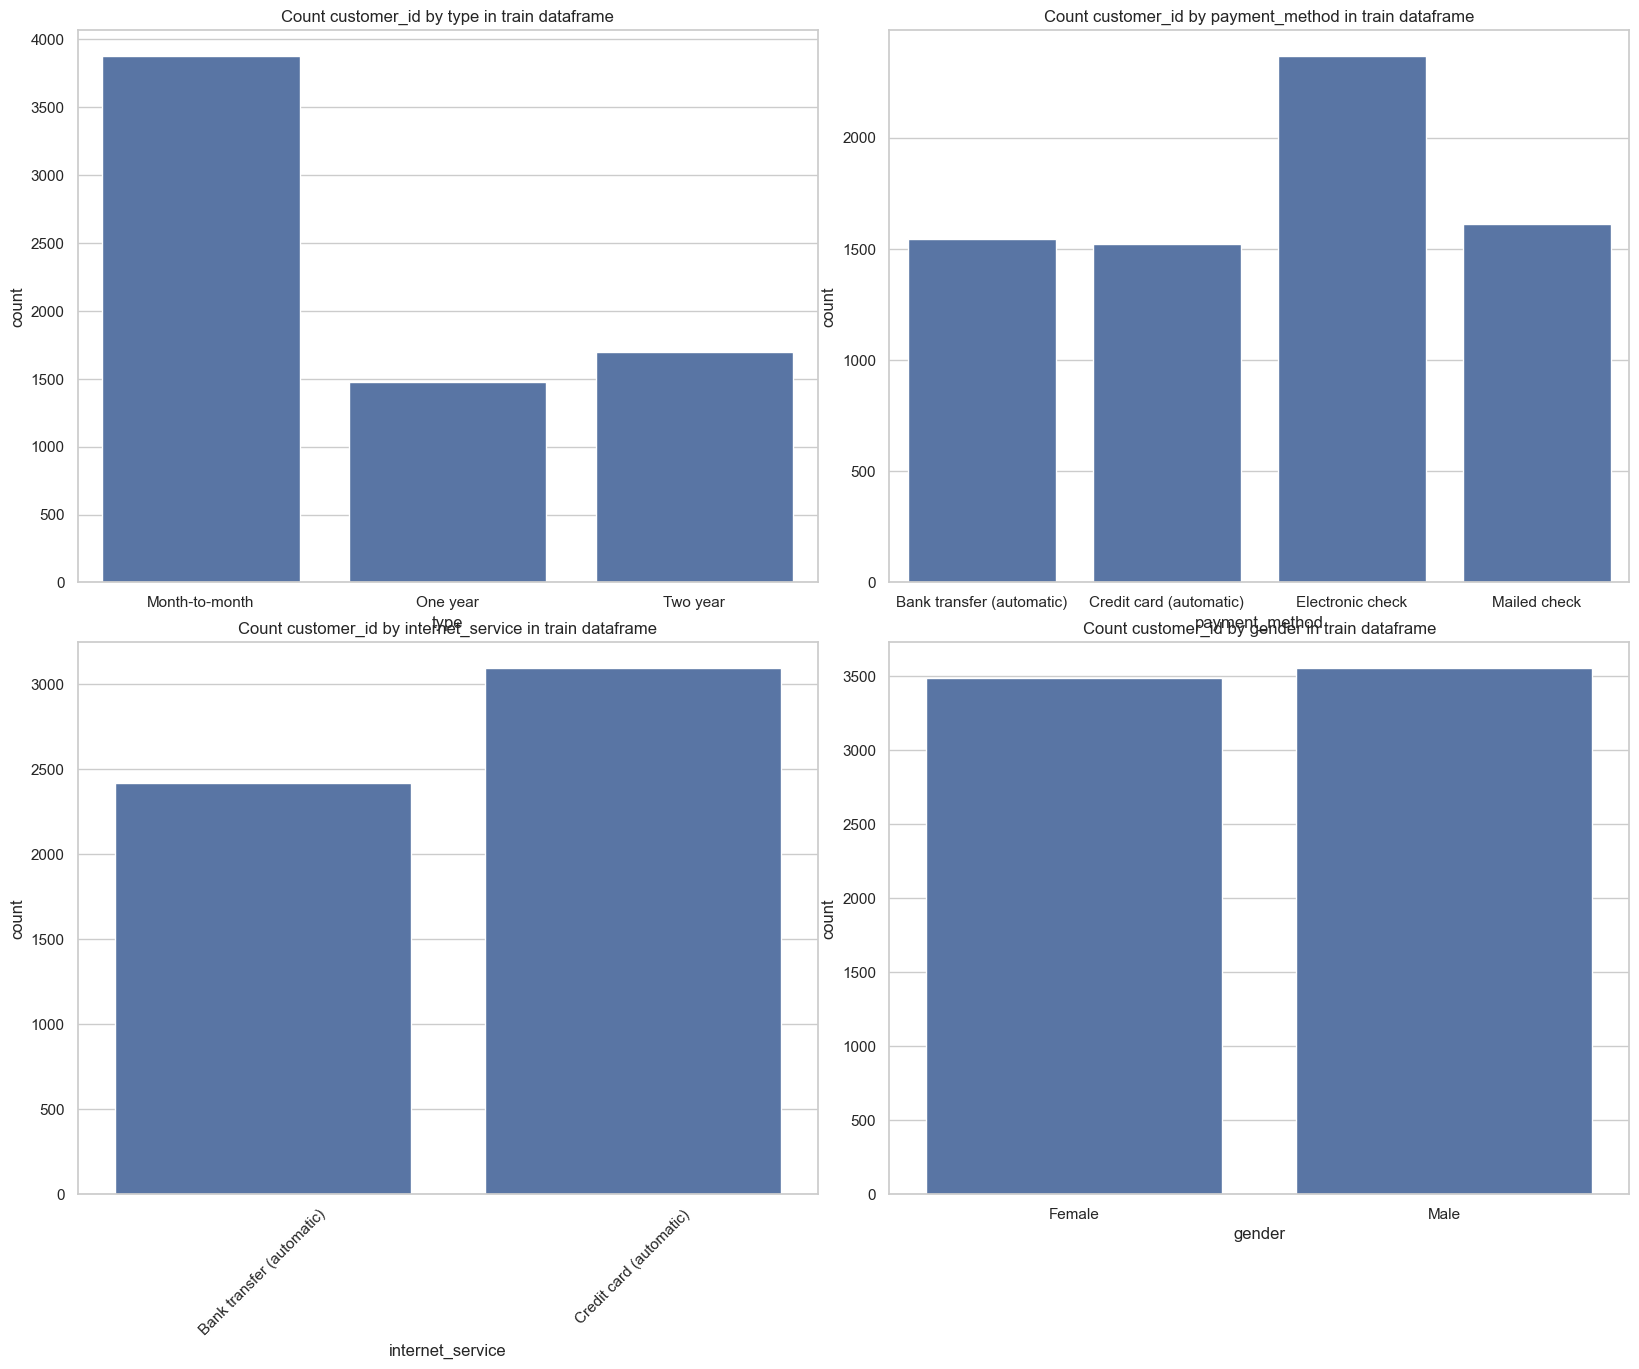

In [ ]:
# Постройте графики количества уникальных пользователей (customer_id), распределённых по таким группам:
# пользователи по различным type,
# пользователи по различным payment_method,
# пользователи по различным internet_service,
# пользователи по различным gender.
# Создайте одну фигуру размером 16.5x12.5 с четырьмя графиками по списку выше. Сохраните вашу картинку в директорию ASSETS_DIR, а файл назовите cat_features_1.

fig, axs = plt.subplots(2, 2)
fig.set_size_inches(16.5, 12.5, forward=True)
fig.tight_layout(pad=1.6)


x = "type"
y = "customer_id"
stat = ["count"]
agg_df = df.groupby(x)[y].agg(stat).reset_index()
print(agg_df.head())
sns.barplot(data=agg_df, x=x, y=stat[0], ax=axs[0, 0])
axs[0, 0].set_title(f"Count {y} by {x} in train dataframe")

x = "payment_method"
y = "customer_id"
agg_df = df.groupby(x)[y].agg(stat).reset_index()
sns.barplot(data=agg_df, x=x, y=stat[0], ax=axs[0, 1])
axs[0, 1].set_title(f"Count {y} by {x} in train dataframe")

axs[1, 0].set_xticklabels(agg_df[x].unique(), rotation=45)

x = "internet_service"
y = "customer_id"
stat = ["count"]
agg_df = df.groupby(x)[y].agg(stat).reset_index()
sns.barplot(data=agg_df, x=x, y=stat[0], ax=axs[1, 0])
axs[1, 0].set_title(f"Count {y} by {x} in train dataframe")


x = "gender"
y = "customer_id"
stat = ["count"]
agg_df = df.groupby(x)[y].agg(stat).reset_index()
sns.barplot(data=agg_df, x=x, y=stat[0], ax=axs[1, 1])
axs[1, 1].set_title(f"Count {y} by {x} in train dataframe")

plt.savefig(os.path.join(ASSETS_DIR, "cat_features_1"))

In [17]:
x = "customer_id"
binary_columns = [
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "senior_citizen",
    "partner",
    "dependents",
]
stat = ["count"]

print(
    df.groupby(binary_columns)
    .agg(stat[0])[x]
    .reset_index()
    .sort_values(by=x, ascending=False)
    .head(10)
)

    online_security online_backup device_protection tech_support streaming_tv  \
0                No            No                No           No           No   
106              No           Yes                No           No           No   
414             Yes           Yes               Yes          Yes          Yes   
4                No            No                No           No           No   
8                No            No                No           No           No   
15               No            No                No           No          Yes   
214             Yes            No                No           No           No   
22               No            No                No           No          Yes   
413             Yes           Yes               Yes          Yes          Yes   
3                No            No                No           No           No   

    streaming_movies  senior_citizen partner dependents  customer_id  
0                 No               0 

In [18]:
binary_columns = [
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies",
    "senior_citizen",
    "partner",
    "dependents",
]

# Большие таблицы не всегда легко анализировать. Чтобы ускорить этот процесс, можно построить тепловую карту бинарных признаков. Ваша задача — построить её для тех же бинарных признаков. По оси
# x у вас должны быть значения 0, 1 по оси
# y — названия признаков. В конце сохраните получившийся график в директорию с артефактами с названием cat_features_2_binary_heatmap.
# подсказка: Тепловая карта строится при помощи функции heatmap. Используйте транспонирование значений из вашего датафрейма.

heat_df = df[binary_columns].apply(lambda x: x.value_counts()).T
sns.heatmap(heat_df, annot=True, cmap="YlGnBu")
plt.savefig("artifacts/cat_features_2_binary_heatmap")

TypeError: '<' not supported between instances of 'int' and 'str'

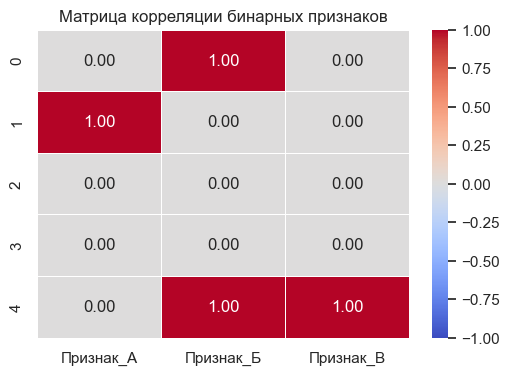

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Генерируем тестовый датасет с бинарными признаками (0 и 1)
np.random.seed(42)
data = pd.DataFrame(
    {
        "Признак_А": np.random.randint(0, 2, 5),
        "Признак_Б": np.random.randint(0, 2, 5),
        "Признак_В": np.random.randint(0, 2, 5),
    }
)

# 2. Считаем матрицу корреляции
corr_matrix = data.corr()

# 3. Строим тепловую карту
plt.figure(figsize=(6, 4))
sns.heatmap(
    data=data,
    annot=True,  # Выводим коэффициенты внутри ячеек
    cmap="coolwarm",  # Идеальная палитра для корреляции (синий -> белый -> красный)
    vmin=-1,
    vmax=1,  # Фиксируем границы шкалы от -1 до 1
    fmt=".2f",  # Округляем значения до 2 знаков после запятой
    linewidths=0.5,  # Добавляем сетку между ячейками
)

plt.title("Матрица корреляции бинарных признаков")
plt.show()

In [ ]:
heat_df = df[binary_columns].apply(pd.Series.value_counts).T
sns.heatmap(heat_df)
plt.savefig(os.path.join(ASSETS_DIR, "cat_features_2_binary_heatmap"))

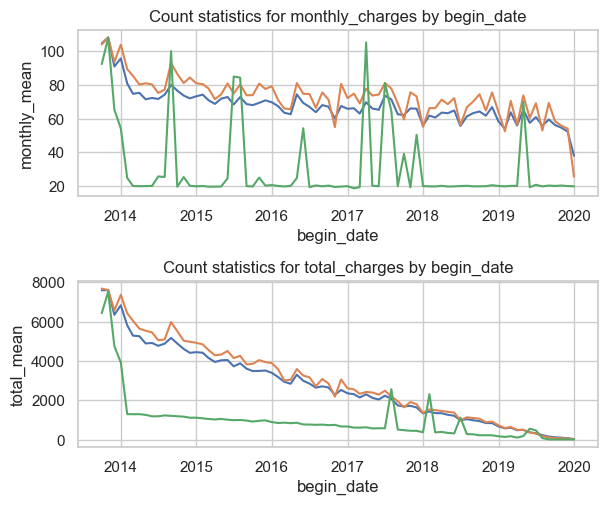

In [24]:
# инициализация переменной для названия колонки
x = "begin_date"

# список колонок, для которых будут вычисляться статистики
charges_columns = [
    "monthly_charges",
    "total_charges",
]

# удаление пустых колонок для посчёта медианного значения
df.dropna(subset=charges_columns, how="any", inplace=True)

# список статистик, которые будут вычисляться для каждой группы
stats = [
    "mean",
    "median",
    lambda x: x.mode().iloc[0],
]  # среднее значение, медиана и мода

# группировка данных по дате начала и агрегация статистик для ежемесячных платежей (используйте reset_index для сброса индекса в таблице)
charges_monthly_agg = (
    df[[x] + [charges_columns[0]]].groupby([x]).agg(stats).reset_index()
)
# удаление верхнего уровня индекса колонок (после агрегации)
charges_monthly_agg.columns = charges_monthly_agg.columns.droplevel()
# переименование колонок для удобства восприятия
charges_monthly_agg.columns = [
    x,
    "monthly_mean",
    "monthly_median",
    "monthly_mode",
]

# аналогично для общих платежей
charges_total_agg = (
    df[[x] + [charges_columns[1]]].groupby([x]).agg(stats).reset_index()
)
charges_total_agg.columns = charges_total_agg.columns.droplevel()
charges_total_agg.columns = [x, "total_mean", "total_median", "total_mode"]

# создание объекта для отображения графиков (2 графика вертикально)
fig, axs = plt.subplots(2, 1)  # ваш код здесь #
# настройка отступов между графиками
fig.tight_layout(pad=2.5)
# установка размера фигуры
fig.set_size_inches(6.5, 5.5, forward=True)

# построение линейных графиков для ежемесячных платежей
# ваш код здесь #
sns.lineplot(charges_monthly_agg, ax=axs[0], x=x, y="monthly_mean")
sns.lineplot(charges_monthly_agg, ax=axs[0], x=x, y="monthly_median")
sns.lineplot(charges_monthly_agg, ax=axs[0], x=x, y="monthly_mode")
# установка заголовка для верхнего графика
axs[0].set_title(f"Count statistics for {charges_columns[0]} by {x}")

# построение линейных графиков для общих платежей
sns.lineplot(charges_total_agg, ax=axs[1], x=x, y="total_mean")
sns.lineplot(charges_total_agg, ax=axs[1], x=x, y="total_median")
sns.lineplot(charges_total_agg, ax=axs[1], x=x, y="total_mode")
# установка заголовка для нижнего графика
axs[1].set_title(f"Count statistics for {charges_columns[1]} by {x}")

# сохранение графика в файл
# ваш код здесь #
plt.savefig(os.path.join(ASSETS_DIR, "charges_by_date"))
# ваш код здесь #

In [ ]:
# директория для сохранения картинок
ASSETS_DIR = "assets"  # ваш код здесь #

# установка названия колонки для агрегации
x = "target"

# подсчёт количества каждого уникального значения в колонке и сброс индекса для последующей визуализации
target_agg = df[x].value_counts().reset_index()  # ваш код здесь #
# target_agg.columns = [x, "count"]

# создание столбчатой диаграммы для визуализации распределения целевой переменной
# ваш код здесь #
sns.barplot(data=target_agg, x="index", y="count")

# установка заголовка графика
plt.title(f"{x} total distribution")

# сохранение графика в файл
# ваш код здесь #
plt.savefig(os.path.join(ASSETS_DIR, "target_count"))

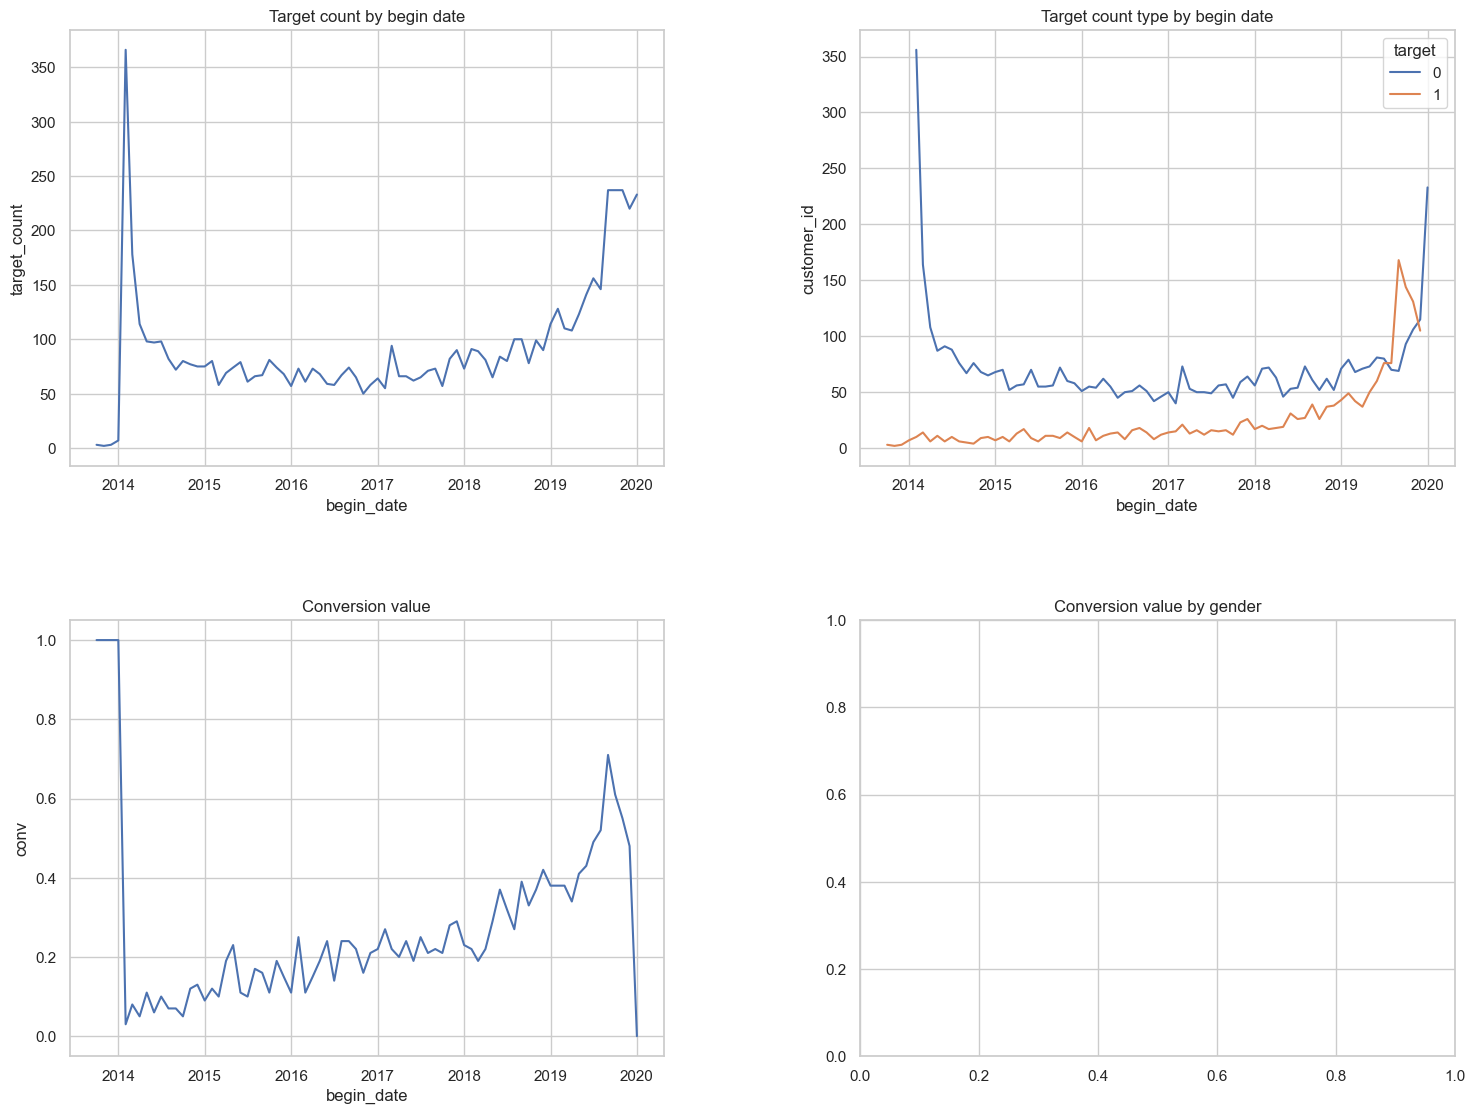

In [29]:
# установка переменных для анализа
x = "begin_date"
target = "target"

# определение статистики для агрегации
stat = ["count"]

# агрегация количества целей по датам начала с последующим сбросом индекса
target_agg_by_date = df[[x, target]].groupby([x]).agg(stat).reset_index()
# удаление мультиуровневости заголовков после агрегации и переименование для удобства
target_agg_by_date.columns = target_agg_by_date.columns.droplevel()
target_agg_by_date.columns = [x, "target_count"]

# подсчёт количества клиентов для каждого значения цели по датам
target_agg = (
    df[[x, target, "customer_id"]].groupby([x, target]).count().reset_index()
)

# расчёт суммы и количества для конверсии по датам
conversion_agg = (
    df[[x, target]].groupby([x])["target"].agg(["sum", "count"]).reset_index()
)
# вычисление коэффициента конверсии и округление до двух знаков
conversion_agg["conv"] = (
    conversion_agg["sum"] / conversion_agg["count"]
).round(
    2
)  # ваш код здесь #

# аналогичный расчет конверсии, но с дополнительным разделением по полу
conversion_agg_gender = (
    df[[x, target, "gender"]]
    .groupby([x, "gender"])[target]
    .agg(["sum", "count"])
    .reset_index()
)
conversion_agg_gender["conv"] = (
    conversion_agg_gender["sum"] / conversion_agg_gender["count"]
).round(
    2
)  # ваш код здесь #

# инициализация фигуры для отображения нескольких графиков
fig, axs = plt.subplots(2, 2)
fig.tight_layout(pad=1.6)  # настройка отступов между подграфиками
fig.set_size_inches(16.5, 12.5, forward=True)  # установка размера фигуры

# визуализация общего количества целей по датам начала
# ваш код здесь #
sns.lineplot(data=target_agg, x=x, y="customer_id", hue=target, ax=axs[0, 1])
axs[0, 0].set_title("Target count by begin date")

# визуализация количества клиентов для каждого типа цели по датам
# ваш код здесь #
sns.lineplot(data=target_agg_by_date, x=x, y="target_count", ax=axs[0, 0])
axs[0, 1].set_title("Target count type by begin date")

# визуализация коэффициента конверсии по датам
# ваш код здесь #
sns.lineplot(data=conversion_agg, x=x, y="conv", ax=axs[1, 0])
axs[1, 0].set_title("Conversion value")

# визуализация коэффициента конверсии по датам с разделением по полу
# ваш код здесь #
# sns.lineplot(
#    data=conversion_agg_gender, x=x, y="conv", hue="gender", ax=axs[1, 1]
# )
axs[1, 1].set_title("Conversion value by gender")

# сохранение визуализации в файл
plt.savefig(os.path.join(ASSETS_DIR, "target_by_date"))

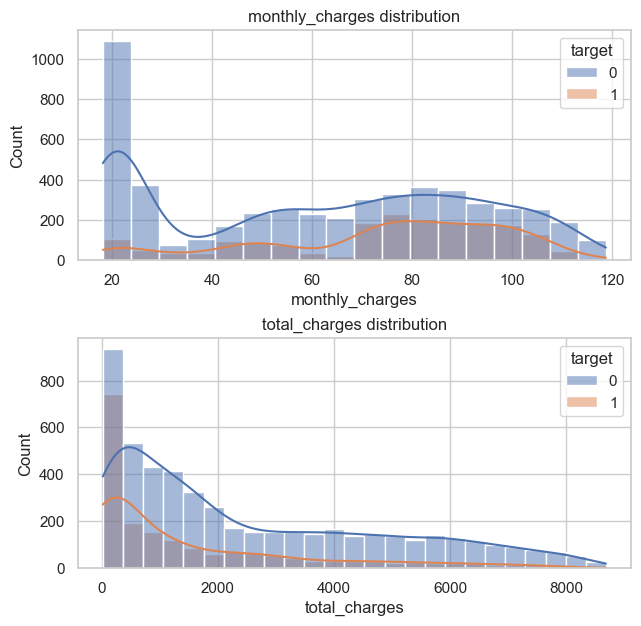

In [31]:
# определение списка столбцов с данными о платежах и целевой переменной
charges = ["monthly_charges", "total_charges"]
target = "target"

# инициализация фигуры для отображения гистограмм
fig, axs = plt.subplots(2, 1)
fig.tight_layout(pad=1.5)  # настройка отступов между подграфиками
fig.set_size_inches(6.5, 6.5, forward=True)  # установка размера фигуры

# визуализация распределения ежемесячных платежей с разделением по целевой переменной
# ваш код здесь #
# датафрейм с данными
# первый вид платежей для визуализации
# разделение данных по целевой переменной
# включение оценки плотности распределения (Kernel Density Estimate)
# указание, на каком подграфике отобразить гистограмму
sns.histplot(data=df, x=charges[0], hue=target, kde=True, ax=axs[0])
axs[0].set_title(
    f"{charges[0]} distribution"
)  # установка заголовка для гистограммы

# визуализация распределения общих платежей с разделением по целевой переменной
# ваш код здесь #
# датафрейм с данными
# второй вид платежей для визуализации
# разделение данных по целевой переменной
# включение оценки плотности распределения
# указание, на каком подграфике отобразить вторую гистограмму
sns.histplot(data=df, x=charges[1], hue=target, kde=True, ax=axs[1])
axs[1].set_title(
    f"{charges[1]} distribution"
)  # Установка заголовка для второй гистограммы

# сохранение фигуры с гистограммами в файл
# ваш код здесь #
plt.savefig(os.path.join(ASSETS_DIR, "chargest_by_target_dist"))